# 06 — Event analysis: Bonfire Night and England World Cup 2026 matches

Hourly-resolution event studies on the cleaned, humidity-corrected network. All network-level results use the median across sensors, which is robust to any single misbehaving sensor. A sensor-hour needs at least `MIN_READ_PER_HOUR` readings; a network-hour needs at least `MIN_SENSORS_PER_HOUR` sensors reporting.

Bonfire Night is the strong-signal case: a known, dated, city-wide combustion event that the network should detect clearly if it is working. The World Cup matches are the weak-signal case, included to show where the network's sensitivity runs out.

Timestamps are UTC in the raw data; events are defined in Europe/London and
converted. The event window (17:00 on 5 November to 01:00 on the 6th), the
control window (25 October to 15 November) and the excluded dates (2–7
November) all come from `config.py`, so this notebook, NB07 and NB08 measure
the same thing.

The hourly table below holds all sensors with any clean data, which is a wider
set than the 43 that pass `MIN_VALID_DAYS` for the CSI in NB05. The event
result uses the network median, so the difference does not change it, but the
two notebooks are not describing the same sensors.

In [ ]:
import re
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.config import *
from src.cleaning import apply_humidity_correction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import contextily as cx


def short_code(name): 
    m = re.search(r"SL_?(\d+)", str(name))
    return f"SL{int(m.group(1)):03d}" if m else str(name)

### Build (and cache) the per-sensor hourly table and the network median

In [11]:
CACHE_HM  = HOURLY_MATRIX

if CACHE_HM.exists():
    hm = pd.read_parquet(CACHE_HM)
    hm.index = pd.to_datetime(hm.index, utc=True)
    print(f"loaded cached per-sensor hourly table: {hm.shape}")
else:
    hourly = {}
    for path in sorted(CLEANED.glob("*.parquet")):
        df = pd.read_parquet(path)
        clean = df[df["is_clean"]].copy()
        if clean.empty:
            continue
        clean[DATE_COL]    = pd.to_datetime(clean[DATE_COL], utc=True)
        clean["pm25_corr"] = apply_humidity_correction(clean)
        clean = clean.dropna(subset=["pm25_corr"])
        agg = (clean.set_index(DATE_COL)["pm25_corr"]
                    .resample("h").agg(["mean", "count"]))
        hourly[path.stem] = agg.loc[agg["count"] >= MIN_READ_PER_HOUR, "mean"]
        print(f"  {path.stem}: {hourly[path.stem].notna().sum():,} valid hours")
    hm = pd.DataFrame(hourly).sort_index()
    hm.to_parquet(CACHE_HM)

n_sensors = hm.notna().sum(axis=1)
net       = hm.median(axis=1).where(n_sensors >= MIN_SENSORS_PER_HOUR)

net_local = net.copy();       net_local.index = net_local.index.tz_convert(LOCAL_TZ)
n_local   = n_sensors.copy(); n_local.index   = n_local.index.tz_convert(LOCAL_TZ)
print(f"network hourly median: {net.notna().sum():,} of {len(net):,} hours valid")

loaded cached per-sensor hourly table: (38753, 47)
network hourly median: 36,011 of 38,753 hours valid


## 1. Bonfire Night — wide time series with sensor-count strips

Per year: 25 Oct – 12 Nov network median (top), sensors reporting per hour (bottom). Gaps in the line are hours failing the `MIN_SENSORS_PER_HOUR` rule — the strip shows exactly why. Grey bands mark Fri/Sat evenings (organised displays); orange marks the bonfire evening itself. Four full-width panels are a lot of page for a result the composite figure below states more compactly, so this is an appendix figure.

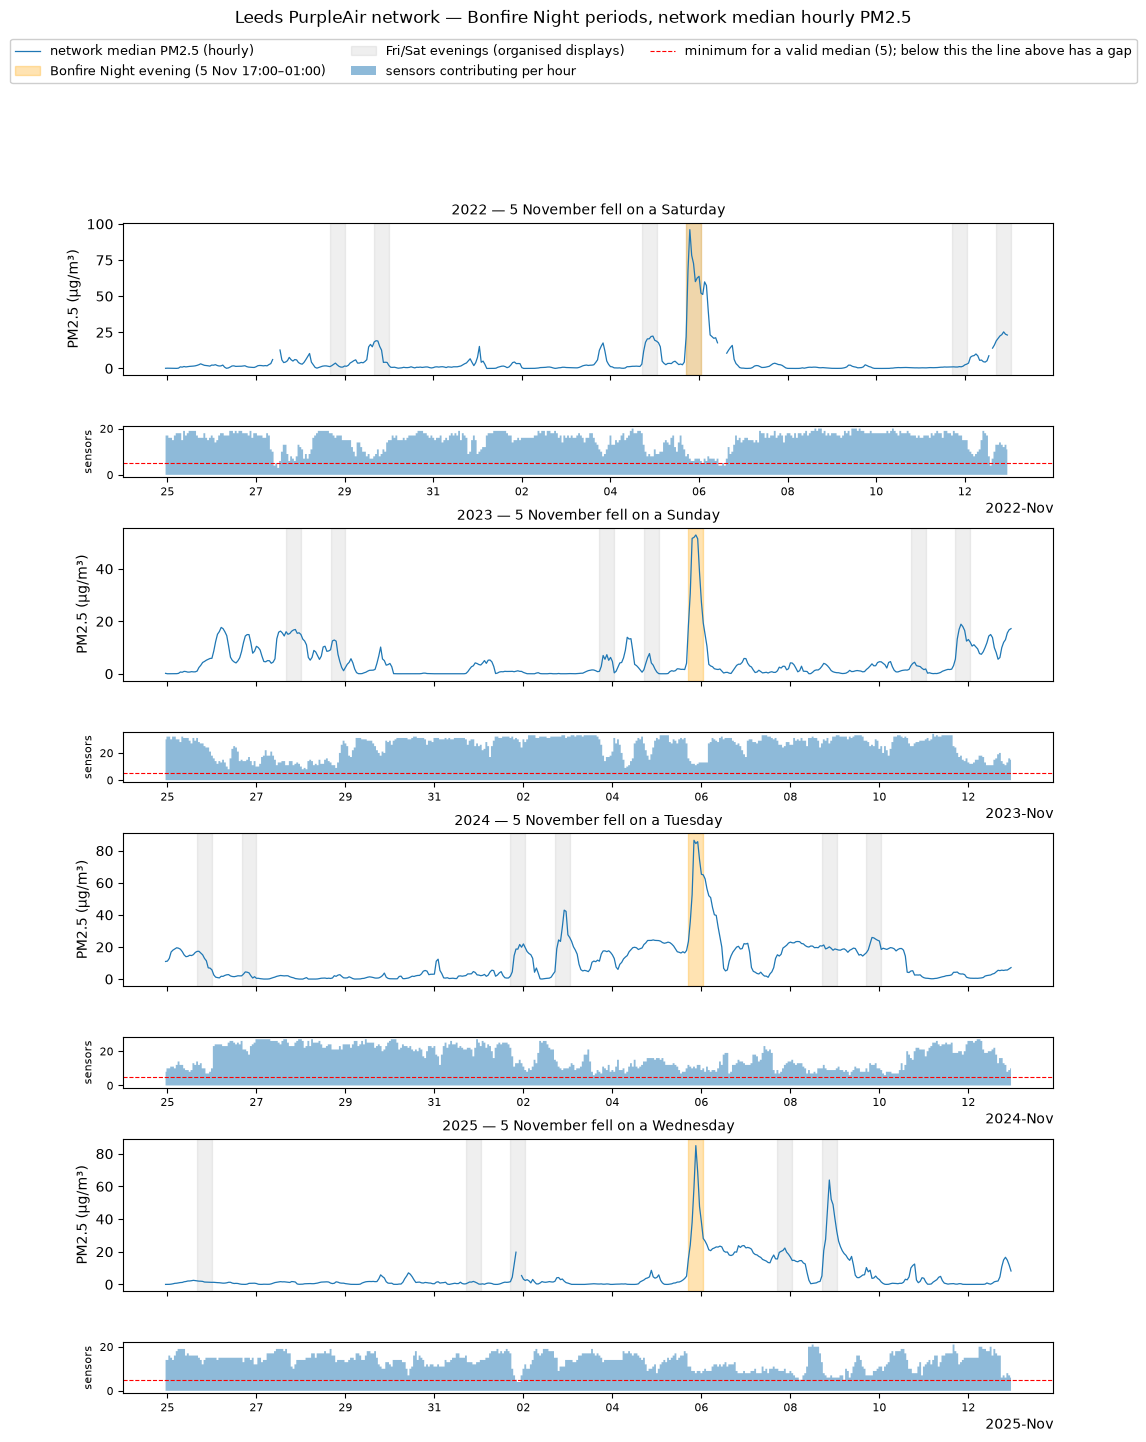

In [12]:
fig = plt.figure(figsize=(12, 3.8 * len(BONFIRE_YEARS)))
gs  = fig.add_gridspec(2 * len(BONFIRE_YEARS), 1,
                       height_ratios=[3, 1] * len(BONFIRE_YEARS),
                       hspace=0.5)

for k, yr in enumerate(BONFIRE_YEARS):
    ax  = fig.add_subplot(gs[2 * k])
    axn = fig.add_subplot(gs[2 * k + 1], sharex=ax)

    t0, t1 = f"{yr}-10-25", f"{yr}-11-12"
    win, nwin = net_local.loc[t0:t1], n_local.loc[t0:t1]

    # --- main panel -----------------------------------------------------
    ax.plot(win.index, win.values, lw=0.9,
            label="network median PM2.5 (hourly)")
    ev = pd.Timestamp(f"{yr}-11-05 {EVENT_START_HOUR:02d}:00", tz=LOCAL_TZ)
    ax.axvspan(ev, ev + pd.Timedelta(hours=EVENT_N_HOURS), color="orange", alpha=0.3,
               label="Bonfire Night evening (5 Nov 17:00\u201301:00)")
    first = True
    for d in pd.date_range(t0, t1, tz=LOCAL_TZ):
        if d.dayofweek in (4, 5):
            ax.axvspan(d + pd.Timedelta(hours=17),
                       d + pd.Timedelta(hours=25), color="grey", alpha=0.12,
                       label="Fri/Sat evenings (organised displays)"
                             if first else None)
            first = False
    wd = pd.Timestamp(f"{yr}-11-05").strftime("%A")
    ax.set_title(f"{yr} — 5 November fell on a {wd}", fontsize=10)
    ax.set_ylabel("PM2.5 (\u00b5g/m\u00b3)")
    ax.tick_params(labelbottom=False)          # dates live on the strip below

    # --- sensor strip ----------------------------------------------------
    axn.fill_between(nwin.index, nwin.values, step="mid", alpha=0.5,
                     label="sensors contributing per hour")
    axn.axhline(MIN_SENSORS_PER_HOUR, color="red", ls="--", lw=0.8,
                label=f"minimum for a valid median ({MIN_SENSORS_PER_HOUR}); "
                      f"below this the line above has a gap")
    axn.set_ylabel("sensors", fontsize=8)
    axn.tick_params(labelsize=8)

    # fresh locator/formatter PER AXIS — these objects must not be shared
    loc = mdates.DayLocator(interval=2)
    axn.xaxis.set_major_locator(loc)
    axn.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

    if k == 0:                                  # one legend for the whole figure
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = axn.get_legend_handles_labels()
        fig.legend(h1 + h2, l1 + l2, loc="upper center",
                   bbox_to_anchor=(0.5, 1.005), ncols=3, fontsize=9,
                   framealpha=0.95)

fig.suptitle("Leeds PurpleAir network — Bonfire Night periods, "
             "network median hourly PM2.5", y=1.02, fontsize=12)
fig.savefig(Figures / "bonfire_timeseries_wide.png", dpi=150,
            bbox_inches="tight")
plt.show()

### Diurnal composite, noon 5 Nov -> noon 6 Nov

Re-centred so the whole event arc (rise ~17:00, peak ~21:00, overnight decay) sits unbroken mid-frame. Controls are the same noon->noon clock window on ordinary days (windows starting 2–7 Nov excluded so surrounding-display evenings don't contaminate the baseline).

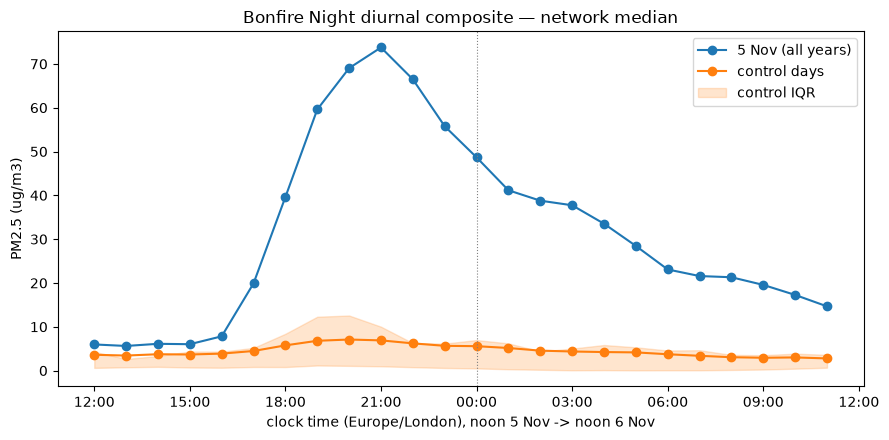

In [13]:
def noon_window(series, day, tz=LOCAL_TZ):
    """Slice noon on `day` -> noon next day; index = hours since noon."""
    t0 = pd.Timestamp(f"{day} 12:00", tz=tz)
    s  = series.loc[t0: t0 + pd.Timedelta(hours=23, minutes=59)].copy()
    s.index = ((s.index - t0).total_seconds() / 3600).astype(int)
    return s

ev_curves, ctl_curves = [], []
for yr in BONFIRE_YEARS:
    e = noon_window(net_local, f"{yr}-11-05")
    if e.notna().sum():
        ev_curves.append(e)
    for d in pd.date_range(f"{yr}-{CONTROL_START}", f"{yr}-{CONTROL_END}"):
        if d.strftime("%m-%d") not in EVENT_EXCLUDE:
            c = noon_window(net_local, d.date())
            if c.notna().sum() >= 12:
                ctl_curves.append(c)

ev_mean  = pd.concat(ev_curves,  axis=1).mean(axis=1)
ctl_all  = pd.concat(ctl_curves, axis=1)
ctl_mean = ctl_all.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ev_mean.index,  ev_mean.values,  marker="o", label="5 Nov (all years)")
ax.plot(ctl_mean.index, ctl_mean.values, marker="o", label="control days")
ax.fill_between(ctl_mean.index,
                ctl_all.quantile(0.25, axis=1),
                ctl_all.quantile(0.75, axis=1), alpha=0.2, color="tab:orange", label="control IQR")
ticks = range(0, 25, 3)
ax.set_xticks(list(ticks))
ax.set_xticklabels([f"{(12 + h) % 24:02d}:00" for h in ticks])
ax.axvline(12, color="grey", ls=":", lw=0.8)   # midnight
ax.set_xlabel(f"clock time ({LOCAL_TZ}), noon 5 Nov -> noon 6 Nov")
ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title("Bonfire Night diurnal composite — network median")
ax.legend()
fig.tight_layout()
fig.savefig(Figures / "bonfire_composite_noon.png", dpi=150)
plt.show()

### Enhancement table 

Event window 17:00 on the 5th to 01:00 on the 6th (timestamps, so the midnight crossing is handled); controls are the same clock window over 25 Oct – 15 Nov, excluding 2–7 Nov so that neighbouring organised displays stay out of the baseline. All four values come from `config.py`.

In [14]:
# One definition of the event and control windows, shared with NB07 and NB08.
EVENT_HOURS = list(range(EVENT_START_HOUR, 24)) + list(range(0, (EVENT_START_HOUR + EVENT_N_HOURS) % 24))

rows = []
for yr in BONFIRE_YEARS:
    w0 = pd.Timestamp(f"{yr}-11-05 {EVENT_START_HOUR:02d}:00", tz=LOCAL_TZ)
    ev = net_local.loc[w0: w0 + pd.Timedelta(hours=EVENT_N_HOURS) - pd.Timedelta(minutes=1)]
    if ev.notna().sum() == 0:
        print(f"  {yr}: no valid network hours in the event window — skipped")
        continue
    season = net_local.loc[f"{yr}-{CONTROL_START}":f"{yr}-{CONTROL_END}"]
    ctl = season[~season.index.strftime("%m-%d").isin(EVENT_EXCLUDE)]
    ctl = ctl[ctl.index.hour.isin(EVENT_HOURS)]
    rows.append({"year": yr,
                 "event_evening_mean":   round(ev.mean(), 2),
                 "control_evening_mean": round(ctl.mean(), 2),
                 "enhancement":          round(ev.mean() - ctl.mean(), 2),
                 "ratio":                round(ev.mean() / ctl.mean(), 2),
                 "valid_event_hours":    int(ev.notna().sum())})

bonfire_stats = pd.DataFrame(rows)
bonfire_stats.to_csv(Tables / "bonfire_enhancement.csv", index=False)
print("Event window means, network median PM2.5 (µg/m³):")
print(bonfire_stats.to_string(index=False))

Event window means, network median PM2.5 (µg/m³):
 year  event_evening_mean  control_evening_mean  enhancement  ratio  valid_event_hours
 2022               65.38                  6.46        58.92  10.11                  8
 2023               40.41                  5.39        35.02   7.50                  8
 2024               63.52                  7.50        56.02   8.47                  8
 2025               47.11                  4.94        42.17   9.53                  8


### Map — per-sensor bonfire enhancement (all years pooled)

Each sensor's own 5-Nov-evening mean minus its own control-evening mean. Every dot lighting up = city-wide event (not a sensor artefact); the gradient shows where firework activity is most intense. Sensors with < 8 valid event hours or < 30 control hours are dropped.

20 sensors with enough event coverage; range 22.9 to 101.3 ug/m3


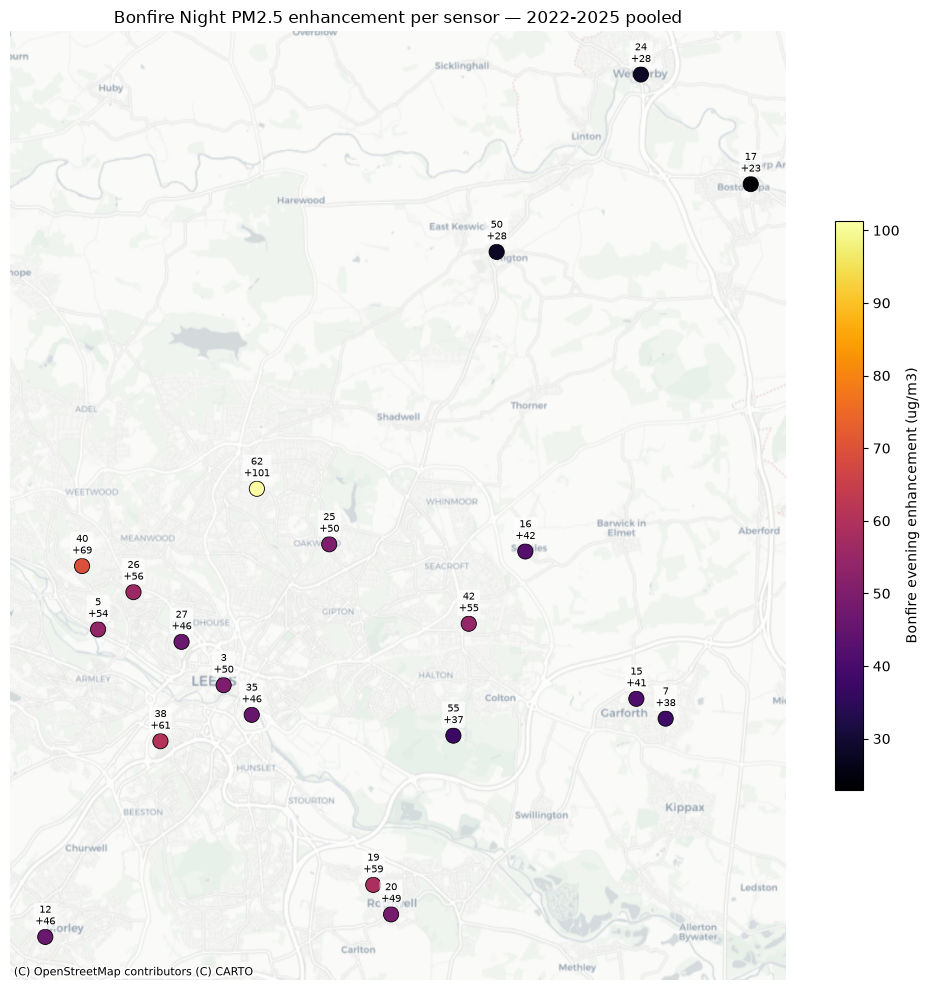

In [15]:
enh = {}
for s in hm.columns:
    x = hm[s].copy()
    x.index = x.index.tz_convert(LOCAL_TZ)
    ev_parts, ctl_parts = [], []
    for yr in BONFIRE_YEARS:
        w0 = pd.Timestamp(f"{yr}-11-05 {EVENT_START_HOUR:02d}:00", tz=LOCAL_TZ)
        ev_parts.append(x.loc[w0: w0 + pd.Timedelta(hours=EVENT_N_HOURS)
                              - pd.Timedelta(minutes=1)])
        c = x.loc[f"{yr}-{CONTROL_START}":f"{yr}-{CONTROL_END}"]
        c = c[~c.index.strftime("%m-%d").isin(EVENT_EXCLUDE)]
        ctl_parts.append(c[c.index.hour.isin(EVENT_HOURS)])
    ev, ctl = pd.concat(ev_parts), pd.concat(ctl_parts)
    if ev.notna().sum() >= 8 and ctl.notna().sum() >= 30:
        enh[short_code(s)] = ev.mean() - ctl.mean()

enh = pd.Series(enh, name="enhancement")
enh.to_csv(Tables / "bonfire_enhancement_per_sensor.csv")
print(f"{len(enh)} sensors with enough event coverage; "
      f"range {enh.min():.1f} to {enh.max():.1f} ug/m3")

sensors = pd.read_csv(Tables / "study_sensors.csv")
sensors["code"] = sensors["sensor_name"].map(short_code)
m = sensors.set_index("code")[["lat", "lon"]].join(enh, how="inner")

fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(m["lon"], m["lat"], c=m["enhancement"], cmap="inferno",
                s=120, edgecolor="black", linewidth=0.6, zorder=3)
for code, row in m.iterrows():
    ax.annotate(f"{code[2:].lstrip('0')}\n+{row.enhancement:.0f}",
                (row["lon"], row["lat"]), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=7, zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", fc="white",
                          ec="none", alpha=0.75))

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
fig.colorbar(sc, ax=ax, shrink=0.6, label="Bonfire evening enhancement (ug/m3)")
ax.set_title("Bonfire Night PM2.5 enhancement per sensor — 2022-2025 pooled")
plt.tight_layout()
plt.savefig(Figures / "bonfire_enhancement_map.png", dpi=200, bbox_inches="tight")
plt.show()